In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import jdatetime as jd
import numpy as np

In [2]:
df = pd.read_csv("divar.csv",low_memory=False)

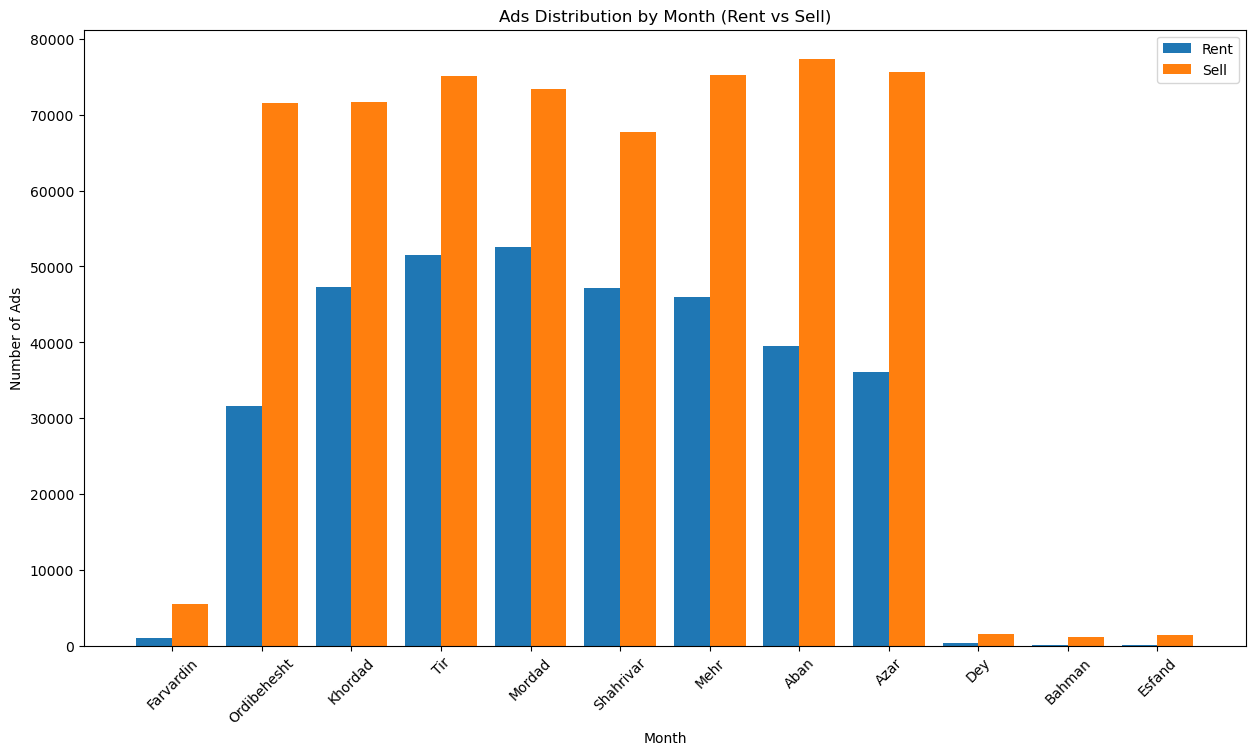

In [3]:
mask = df[df["cat2_slug"].isin(['temporary-rent', 'residential-sell', 'residential-rent', 'commercial-rent','commercial-sell'])].copy()
mask["created_at_month"] = pd.to_datetime(mask["created_at_month"])
mask["Month"] = mask["created_at_month"].apply(lambda x : jd.date.fromgregorian(date=x.date()).strftime("%B"))
mask_sell = mask[mask["cat2_slug"].isin(['residential-sell','commercial-sell'])]
mask_rent = mask[mask["cat2_slug"].isin(['residential-rent', 'commercial-rent'])]
month_order = ['Farvardin','Ordibehesht','Khordad','Tir','Mordad','Shahrivar','Mehr','Aban','Azar','Dey','Bahman','Esfand']
mask_rent_m = mask_rent["Month"].value_counts().reindex(month_order)
mask_sell_m = mask_sell["Month"].value_counts().reindex(month_order)
x = np.arange(len(month_order))
plt.figure(figsize=(15,8))
plt.bar(x - 0.2, mask_rent_m.values, width=0.4, label="Rent")
plt.bar(x + 0.2, mask_sell_m.values, width=0.4, label="Sell")
plt.xticks(x, month_order, rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Ads")
plt.title("Ads Distribution by Month (Rent vs Sell)")
plt.legend()
plt.show()

## In Farvardin ,Dey ,Bahman ,Esfand the number of buy and rent listings is lower. This usually happens because winter weather makes moving and house visits harder. Also, during the end of the year and noruz holidays, people delay big financial decisions. As a result, activity in the housing market decreases in these months.